# Currency Exchange Rate Forecasting
## Notebook 03 — Deep Learning Models

This notebook implements deep learning models for forecasting SGD/USD and CNY/USD 
exchange rates. It continues from `02_ml_models.ipynb` where machine learning 
models were evaluated.

**Models covered:**
- LSTM (Long Short-Term Memory)
- GRU (Gated Recurrent Unit)
- Transformer

**Data:** SGD/USD and CNY/USD daily exchange rates, 2000–2019  
**Train:** 2000-03-29 → 2016-01-18 | **Test:** 2016-01-19 → 2019-12-31

In [2]:
# Standard Library
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Machine Learning utilities
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, r2_score, max_error

# Styling
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print(f"✅ All imports successful")
print(f"TensorFlow version : {tf.__version__}")

✅ All imports successful
TensorFlow version : 2.20.0


In [4]:
# Load raw data
df = pd.read_csv("./data/Foreign_Exchange_Rates.csv")

print(f"Shape : {df.shape}")
df.head()

Shape : (5217, 3)


,DATE,SINGAPORE - SINGAPORE DOLLAR/US$,CHINA - YUAN/US$
0,2000-01-03,1.6563,8.2798
1,2000-01-04,1.6535,8.2799
2,2000-01-05,1.656,8.2798
3,2000-01-06,1.6655,8.2797
4,2000-01-07,1.6625,8.2794


In [5]:
# Rename columns
df.columns = ["date", "sgd_usd", "cny_usd"]

print(df.columns.tolist())
df.head()

['date', 'sgd_usd', 'cny_usd']


,date,sgd_usd,cny_usd
0,2000-01-03,1.6563,8.2798
1,2000-01-04,1.6535,8.2799
2,2000-01-05,1.656,8.2798
3,2000-01-06,1.6655,8.2797
4,2000-01-07,1.6625,8.2794


In [6]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

print(f"Date dtype : {df['date'].dtype}")

Date dtype : datetime64[us]


In [7]:
# Set date as index and sort chronologically
df = df.set_index("date").sort_index()

print(f"Index type : {type(df.index)}")
print(f"Date range : {df.index.min()} → {df.index.max()}")

Index type : <class 'pandas.DatetimeIndex'>
Date range : 2000-01-03 00:00:00 → 2019-12-31 00:00:00


In [8]:
# Replace ND with NaN and convert to numeric
df = df.replace("ND", np.nan)
df["sgd_usd"] = pd.to_numeric(df["sgd_usd"], errors="coerce")
df["cny_usd"] = pd.to_numeric(df["cny_usd"], errors="coerce")

print(f"SGD nulls : {df['sgd_usd'].isna().sum()}")
print(f"CNY nulls : {df['cny_usd'].isna().sum()}")

SGD nulls : 198
CNY nulls : 197


In [9]:
# Forward fill missing values
df = df.ffill()

print(f"SGD nulls after fill : {df['sgd_usd'].isna().sum()}")
print(f"CNY nulls after fill : {df['cny_usd'].isna().sum()}")

SGD nulls after fill : 0
CNY nulls after fill : 0


In [10]:
# Train / test split — 80/20 chronological
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

print(f"Train shape : {train.shape} | {train.index.min().date()} → {train.index.max().date()}")
print(f"Test shape  : {test.shape}  | {test.index.min().date()} → {test.index.max().date()}")

Train shape : (4173, 2) | 2000-01-03 → 2015-12-30
Test shape  : (1044, 2)  | 2015-12-31 → 2019-12-31


In [11]:
# Scale data — MinMaxScaler
scaler_sgd = MinMaxScaler()
scaler_cny = MinMaxScaler()

train_sgd_scaled = scaler_sgd.fit_transform(train[["sgd_usd"]])
train_cny_scaled = scaler_cny.fit_transform(train[["cny_usd"]])

test_sgd_scaled = scaler_sgd.transform(test[["sgd_usd"]])
test_cny_scaled = scaler_cny.transform(test[["cny_usd"]])

print(f"Train SGD scaled shape : {train_sgd_scaled.shape}")
print(f"Train CNY scaled shape : {train_cny_scaled.shape}")

Train SGD scaled shape : (4173, 1)
Train CNY scaled shape : (4173, 1)


In [12]:
# Create sequences for LSTM/GRU
# Each sample: 60 days of history → predict next day
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 60

X_train_sgd, y_train_sgd = create_sequences(train_sgd_scaled, seq_length)
X_train_cny, y_train_cny = create_sequences(train_cny_scaled, seq_length)

print(f"X_train_sgd shape : {X_train_sgd.shape}")
print(f"y_train_sgd shape : {y_train_sgd.shape}")

X_train_sgd shape : (4113, 60)
y_train_sgd shape : (4113,)


In [13]:
# Create test sequences
X_test_sgd, y_test_sgd = create_sequences(test_sgd_scaled, seq_length)
X_test_cny, y_test_cny = create_sequences(test_cny_scaled, seq_length)

print(f"X_test_sgd shape : {X_test_sgd.shape}")
print(f"y_test_sgd shape : {y_test_sgd.shape}")

X_test_sgd shape : (984, 60)
y_test_sgd shape : (984,)


In [14]:
# Reshape for LSTM/GRU — requires 3D input (samples, timesteps, features)
X_train_sgd = X_train_sgd.reshape((X_train_sgd.shape[0], X_train_sgd.shape[1], 1))
X_train_cny = X_train_cny.reshape((X_train_cny.shape[0], X_train_cny.shape[1], 1))
X_test_sgd  = X_test_sgd.reshape((X_test_sgd.shape[0], X_test_sgd.shape[1], 1))
X_test_cny  = X_test_cny.reshape((X_test_cny.shape[0], X_test_cny.shape[1], 1))

print(f"X_train_sgd shape : {X_train_sgd.shape}")
print(f"X_test_sgd shape  : {X_test_sgd.shape}")

X_train_sgd shape : (4113, 60, 1)
X_test_sgd shape  : (984, 60, 1)


In [15]:
# Evaluation metrics function
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    maxe = max_error(y_true, y_pred)
    da   = np.mean(np.sign(np.diff(np.array(y_true))) == np.sign(np.diff(np.array(y_pred)))) * 100

    print(f"── {model_name} ──────────────────────────────")
    print(f"RMSE               : {rmse:.6f}")
    print(f"MAE                : {mae:.6f}")
    print(f"MAPE               : {mape:.4f}%")
    print(f"R²                 : {r2:.6f}")
    print(f"Max Error          : {maxe:.6f}")
    print(f"Directional Acc.   : {da:.2f}%")

    return {"model": model_name, "RMSE": rmse, "MAE": mae,
            "MAPE": mape, "R2": r2, "MaxError": maxe, "DA": da}

print("✅ Evaluation function ready")

✅ Evaluation function ready


## 11. Deep Learning Models

We now apply deep learning models to the currency forecasting task. Unlike ML models 
which treat each day independently, deep learning sequence models explicitly model 
the **temporal order** of observations — learning patterns across time.

Each model follows the same workflow:
1. Build model architecture
2. Train on sequences of 60 days
3. Evaluate in-sample performance
4. Generate out-of-sample predictions
5. Evaluate out-of-sample performance
6. Visualise results

| Model | Type | Key Strength |
|---|---|---|
| LSTM | Recurrent Neural Network | Long-term memory via forget/input/output gates |
| GRU | Recurrent Neural Network | Simplified LSTM — faster training |
| Transformer | Attention-based | Captures long-range dependencies directly |

### 11.1 LSTM (Long Short-Term Memory)

LSTM is a type of Recurrent Neural Network (RNN) designed to learn long-term 
dependencies in sequential data. It solves the vanishing gradient problem of 
standard RNNs through three gates:

- **Forget gate:** decides what information to discard from memory
- **Input gate:** decides what new information to store in memory  
- **Output gate:** decides what information to output as prediction

Our architecture:
- Input: 60 days of historical rates
- 2 LSTM layers with Dropout to prevent overfitting
- 1 Dense output layer predicting the next day's rate

In [16]:
# Build LSTM model — SGD
lstm_sgd = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_sgd.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
lstm_sgd.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train LSTM — SGD
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

lstm_sgd_history = lstm_sgd.fit(
    X_train_sgd, y_train_sgd,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("✅ LSTM trained for SGD")

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0205 - val_loss: 6.4916e-04
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0042 - val_loss: 3.2242e-04
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0040 - val_loss: 3.8929e-04
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0038 - val_loss: 2.9204e-04
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0030 - val_loss: 2.9394e-04
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0030 - val_loss: 2.6403e-04
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0030 - val_loss: 3.2442e-04
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0029 - val_loss: 2.6095e-04
Epoch 9/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0026 - val_loss: 4.1225e-04
Epoch 10/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0025 - val_loss: 3.0674e-04
Epoch 11/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0025 - val_los

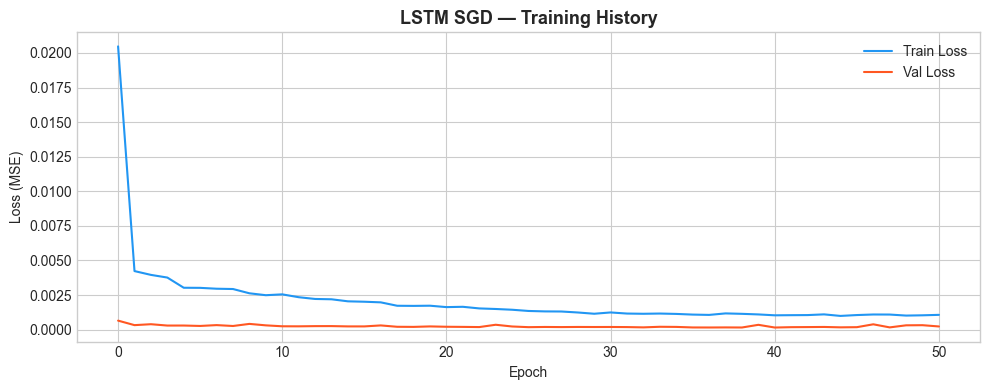

In [18]:
# Plot LSTM SGD training history
plt.figure(figsize=(10, 4))
plt.plot(lstm_sgd_history.history["loss"], label="Train Loss", color="#2196F3")
plt.plot(lstm_sgd_history.history["val_loss"], label="Val Loss", color="#FF5722")
plt.title("LSTM SGD — Training History", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("./reports/28_lstm_sgd_training.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# Build LSTM model — CNY
lstm_cny = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_cny.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

lstm_cny_history = lstm_cny.fit(
    X_train_cny, y_train_cny,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("✅ LSTM trained for CNY")

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0317 - val_loss: 1.8413e-04
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0058 - val_loss: 1.9712e-04
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0052 - val_loss: 2.2537e-04
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0048 - val_loss: 1.7219e-04
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0046 - val_loss: 1.8842e-04
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0045 - val_loss: 2.1861e-04
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0045 - val_loss: 1.5526e-04
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0039 - val_loss: 1.7837e-04
Epoch 9/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0038 - val_loss: 1.8309e-04
Epoch 10/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0039 - val_loss: 1.7492e-04
Epoch 11/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0036 - val_los

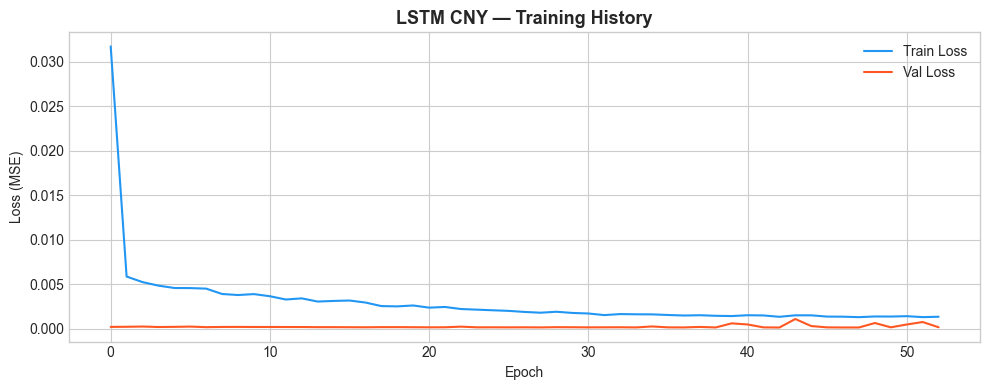

In [20]:
# Plot LSTM CNY training history
plt.figure(figsize=(10, 4))
plt.plot(lstm_cny_history.history["loss"], label="Train Loss", color="#2196F3")
plt.plot(lstm_cny_history.history["val_loss"], label="Val Loss", color="#FF5722")
plt.title("LSTM CNY — Training History", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("./reports/29_lstm_cny_training.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# LSTM — in-sample predictions SGD
lstm_train_pred_sgd = lstm_sgd.predict(X_train_sgd)
lstm_train_pred_sgd = scaler_sgd.inverse_transform(lstm_train_pred_sgd)
y_train_sgd_actual  = scaler_sgd.inverse_transform(y_train_sgd.reshape(-1, 1))

print(f"Train predictions shape : {lstm_train_pred_sgd.shape}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Train predictions shape : (4113, 1)


In [22]:
# LSTM — in-sample predictions CNY
lstm_train_pred_cny = lstm_cny.predict(X_train_cny)
lstm_train_pred_cny = scaler_cny.inverse_transform(lstm_train_pred_cny)
y_train_cny_actual  = scaler_cny.inverse_transform(y_train_cny.reshape(-1, 1))

print(f"Train predictions shape : {lstm_train_pred_cny.shape}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Train predictions shape : (4113, 1)


In [23]:
# LSTM — in-sample evaluation
print("── In-Sample Evaluation ────────────────────────────────")
lstm_train_sgd_metrics = evaluate_model(
    y_train_sgd_actual.flatten(),
    lstm_train_pred_sgd.flatten(),
    "LSTM Train — SGD/USD"
)
print()
lstm_train_cny_metrics = evaluate_model(
    y_train_cny_actual.flatten(),
    lstm_train_pred_cny.flatten(),
    "LSTM Train — CNY/USD"
)

── In-Sample Evaluation ────────────────────────────────
── LSTM Train — SGD/USD ──────────────────────────────
RMSE               : 0.008895
MAE                : 0.007002
MAPE               : 0.4734%
R²                 : 0.998048
Max Error          : 0.048565
Directional Acc.   : 47.40%

── LSTM Train — CNY/USD ──────────────────────────────
RMSE               : 0.024012
MAE                : 0.018748
MAPE               : 0.2479%
R²                 : 0.999239
Max Error          : 0.188309
Directional Acc.   : 42.41%


In [24]:
# LSTM — out-of-sample predictions SGD
lstm_sgd_pred = lstm_sgd.predict(X_test_sgd)
lstm_sgd_pred = scaler_sgd.inverse_transform(lstm_sgd_pred)
y_test_sgd_actual = scaler_sgd.inverse_transform(y_test_sgd.reshape(-1, 1))

print(f"Test predictions shape : {lstm_sgd_pred.shape}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test predictions shape : (984, 1)


In [25]:
# LSTM — out-of-sample predictions CNY
lstm_cny_pred = lstm_cny.predict(X_test_cny)
lstm_cny_pred = scaler_cny.inverse_transform(lstm_cny_pred)
y_test_cny_actual = scaler_cny.inverse_transform(y_test_cny.reshape(-1, 1))

print(f"Test predictions shape : {lstm_cny_pred.shape}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test predictions shape : (984, 1)


In [26]:
# LSTM — evaluate out-of-sample SGD
lstm_sgd_metrics = evaluate_model(
    y_test_sgd_actual.flatten(),
    lstm_sgd_pred.flatten(),
    "LSTM — SGD/USD"
)

── LSTM — SGD/USD ──────────────────────────────
RMSE               : 0.006301
MAE                : 0.004894
MAPE               : 0.3585%
R²                 : 0.945631
Max Error          : 0.023197
Directional Acc.   : 47.10%


In [27]:
# LSTM — evaluate out-of-sample CNY
lstm_cny_metrics = evaluate_model(
    y_test_cny_actual.flatten(),
    lstm_cny_pred.flatten(),
    "LSTM — CNY/USD"
)

── LSTM — CNY/USD ──────────────────────────────
RMSE               : 0.035658
MAE                : 0.025769
MAPE               : 0.3827%
R²                 : 0.971517
Max Error          : 0.163334
Directional Acc.   : 45.07%


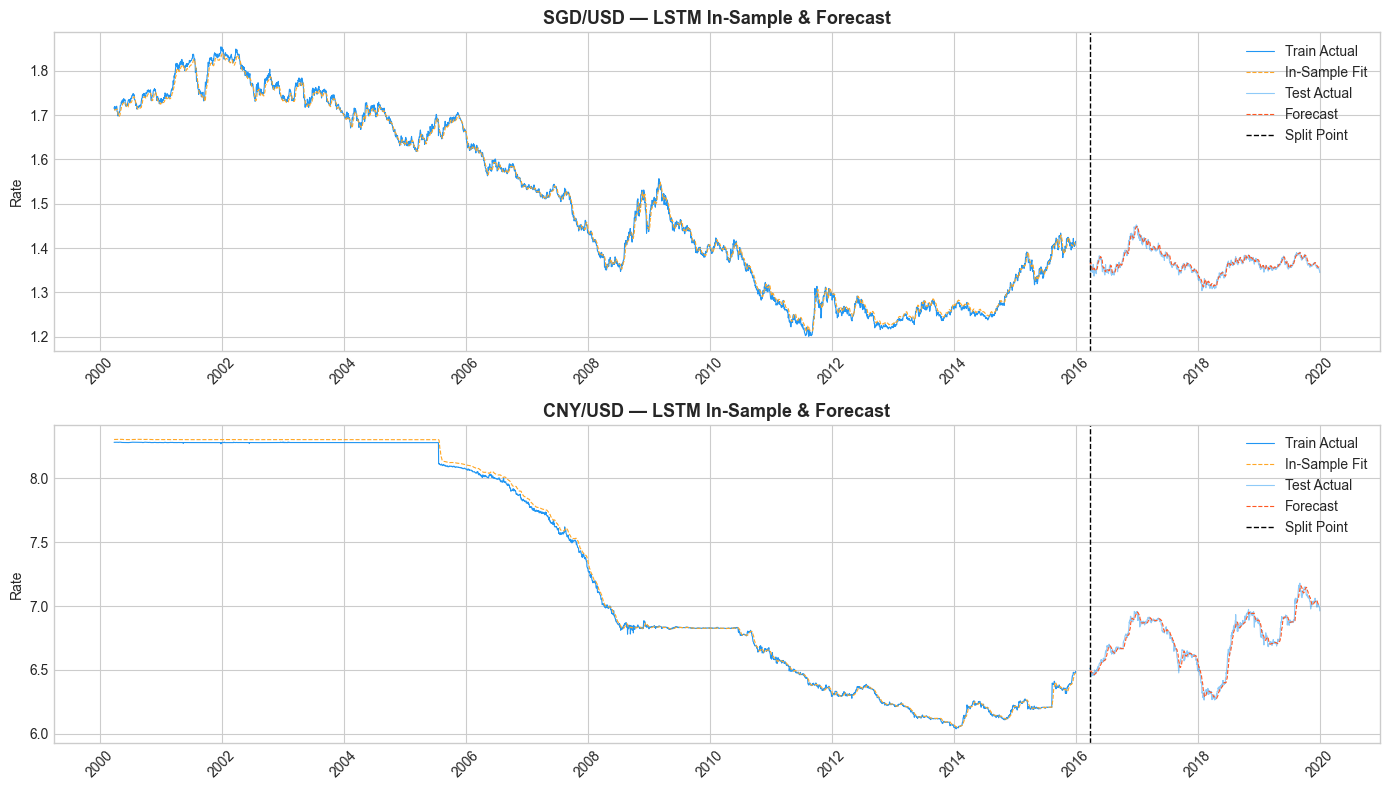

In [28]:
# Plot LSTM — in-sample and out-of-sample
train_dates = train.index[seq_length:]
test_dates  = test.index[seq_length:]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train_dates, y_train_sgd_actual, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(train_dates, lstm_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(test_dates, y_test_sgd_actual, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(test_dates, lstm_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test_dates.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — LSTM In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train_dates, y_train_cny_actual, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(train_dates, lstm_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(test_dates, y_test_cny_actual, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(test_dates, lstm_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test_dates.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — LSTM In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/30_lstm_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### LSTM — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.008895 | 0.006301 | 0.024012 | 0.035658 |
| MAE | 0.007002 | 0.004894 | 0.018748 | 0.025769 |
| MAPE | 0.4734% | 0.3585% | 0.2479% | 0.3827% |
| R² | 0.9980 | 0.9456 | 0.9992 | 0.9715 |
| Max Error | 0.048565 | 0.023197 | 0.188309 | 0.163334 |
| Directional Acc. | 47.40% | 47.10% | 42.41% | 45.07% |

**Key findings:**
- Test RMSE lower than train RMSE for SGD — model generalises better on test data
- CNY R² of 0.9715 — strong level prediction
- Directional accuracy below 50% for both currencies — LSTM struggles with direction
- Visually the best forecast so far — forecast closely tracks actual movements
- **Conclusion:** LSTM excels at level prediction but directional accuracy 
  needs improvement — GRU may offer a better balance

### 11.2 GRU (Gated Recurrent Unit)

GRU is a simplified version of LSTM with only two gates instead of three:

- **Reset gate:** decides how much past information to forget
- **Update gate:** decides how much past information to carry forward

GRU has fewer parameters than LSTM which makes it:
- Faster to train
- Less prone to overfitting on smaller datasets
- Often comparable or better performance than LSTM

Our architecture mirrors the LSTM — 2 GRU layers with Dropout and a Dense output layer.

In [29]:
# Build GRU model — SGD
gru_sgd = Sequential([
    GRU(64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

gru_sgd.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
gru_sgd.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Train GRU — SGD
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

gru_sgd_history = gru_sgd.fit(
    X_train_sgd, y_train_sgd,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("✅ GRU trained for SGD")

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0233 - val_loss: 5.1626e-04
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0049 - val_loss: 3.1657e-04
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0040 - val_loss: 2.0653e-04
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0035 - val_loss: 1.3698e-04
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0031 - val_loss: 1.3519e-04
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0032 - val_loss: 1.3141e-04
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0028 - val_loss: 1.9227e-04
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0028 - val_loss: 1.5182e-04
Epoch 9/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0027 - val_loss: 1.2534e-04
Epoch 10/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0027 - val_loss: 1.9628e-04
Epoch 11/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0025 - val_los

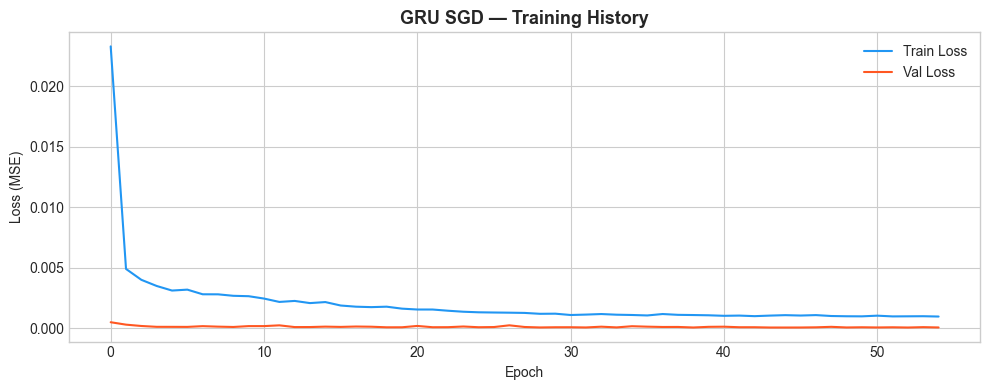

In [31]:
# Plot GRU SGD training history
plt.figure(figsize=(10, 4))
plt.plot(gru_sgd_history.history["loss"], label="Train Loss", color="#2196F3")
plt.plot(gru_sgd_history.history["val_loss"], label="Val Loss", color="#FF5722")
plt.title("GRU SGD — Training History", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("./reports/31_gru_sgd_training.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# Build GRU model — CNY
gru_cny = Sequential([
    GRU(64, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

gru_cny.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

gru_cny_history = gru_cny.fit(
    X_train_cny, y_train_cny,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("✅ GRU trained for CNY")

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0359 - val_loss: 6.2565e-05
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0066 - val_loss: 1.6694e-04
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0058 - val_loss: 6.1395e-05
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0051 - val_loss: 9.9185e-05
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0043 - val_loss: 1.0716e-04
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0044 - val_loss: 7.1202e-05
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0042 - val_loss: 1.5748e-04
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0040 - val_loss: 2.6828e-04
Epoch 9/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0040 - val_loss: 5.9607e-05
Epoch 10/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0036 - val_loss: 1.4732e-04
Epoch 11/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0037 - val_los

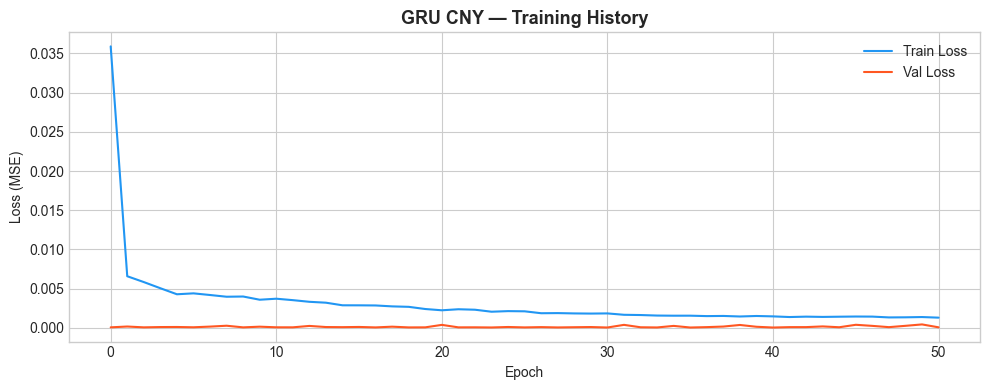

In [33]:
# Plot GRU CNY training history
plt.figure(figsize=(10, 4))
plt.plot(gru_cny_history.history["loss"], label="Train Loss", color="#2196F3")
plt.plot(gru_cny_history.history["val_loss"], label="Val Loss", color="#FF5722")
plt.title("GRU CNY — Training History", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("./reports/32_gru_cny_training.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
# GRU — in-sample predictions
gru_train_pred_sgd = gru_sgd.predict(X_train_sgd)
gru_train_pred_sgd = scaler_sgd.inverse_transform(gru_train_pred_sgd)

gru_train_pred_cny = gru_cny.predict(X_train_cny)
gru_train_pred_cny = scaler_cny.inverse_transform(gru_train_pred_cny)

print(f"Train SGD predictions shape : {gru_train_pred_sgd.shape}")
print(f"Train CNY predictions shape : {gru_train_pred_cny.shape}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Train SGD predictions shape : (4113, 1)
Train CNY predictions shape : (4113, 1)


In [35]:
# GRU — in-sample evaluation
print("── In-Sample Evaluation ────────────────────────────────")
gru_train_sgd_metrics = evaluate_model(
    y_train_sgd_actual.flatten(),
    gru_train_pred_sgd.flatten(),
    "GRU Train — SGD/USD"
)
print()
gru_train_cny_metrics = evaluate_model(
    y_train_cny_actual.flatten(),
    gru_train_pred_cny.flatten(),
    "GRU Train — CNY/USD"
)

── In-Sample Evaluation ────────────────────────────────
── GRU Train — SGD/USD ──────────────────────────────
RMSE               : 0.006414
MAE                : 0.004831
MAPE               : 0.3229%
R²                 : 0.998985
Max Error          : 0.045106
Directional Acc.   : 47.13%

── GRU Train — CNY/USD ──────────────────────────────
RMSE               : 0.012710
MAE                : 0.008060
MAPE               : 0.1113%
R²                 : 0.999787
Max Error          : 0.170119
Directional Acc.   : 41.25%


In [36]:
# GRU — out-of-sample predictions
gru_sgd_pred = gru_sgd.predict(X_test_sgd)
gru_sgd_pred = scaler_sgd.inverse_transform(gru_sgd_pred)

gru_cny_pred = gru_cny.predict(X_test_cny)
gru_cny_pred = scaler_cny.inverse_transform(gru_cny_pred)

print(f"Test SGD predictions shape : {gru_sgd_pred.shape}")
print(f"Test CNY predictions shape : {gru_cny_pred.shape}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test SGD predictions shape : (984, 1)
Test CNY predictions shape : (984, 1)


In [37]:
# GRU — evaluate out-of-sample SGD
gru_sgd_metrics = evaluate_model(
    y_test_sgd_actual.flatten(),
    gru_sgd_pred.flatten(),
    "GRU — SGD/USD"
)

── GRU — SGD/USD ──────────────────────────────
RMSE               : 0.004693
MAE                : 0.003594
MAPE               : 0.2630%
R²                 : 0.969843
Max Error          : 0.022752
Directional Acc.   : 50.56%


In [38]:
# GRU — evaluate out-of-sample CNY
gru_cny_metrics = evaluate_model(
    y_test_cny_actual.flatten(),
    gru_cny_pred.flatten(),
    "GRU — CNY/USD"
)

── GRU — CNY/USD ──────────────────────────────
RMSE               : 0.022967
MAE                : 0.016183
MAPE               : 0.2401%
R²                 : 0.988183
Max Error          : 0.148159
Directional Acc.   : 44.46%


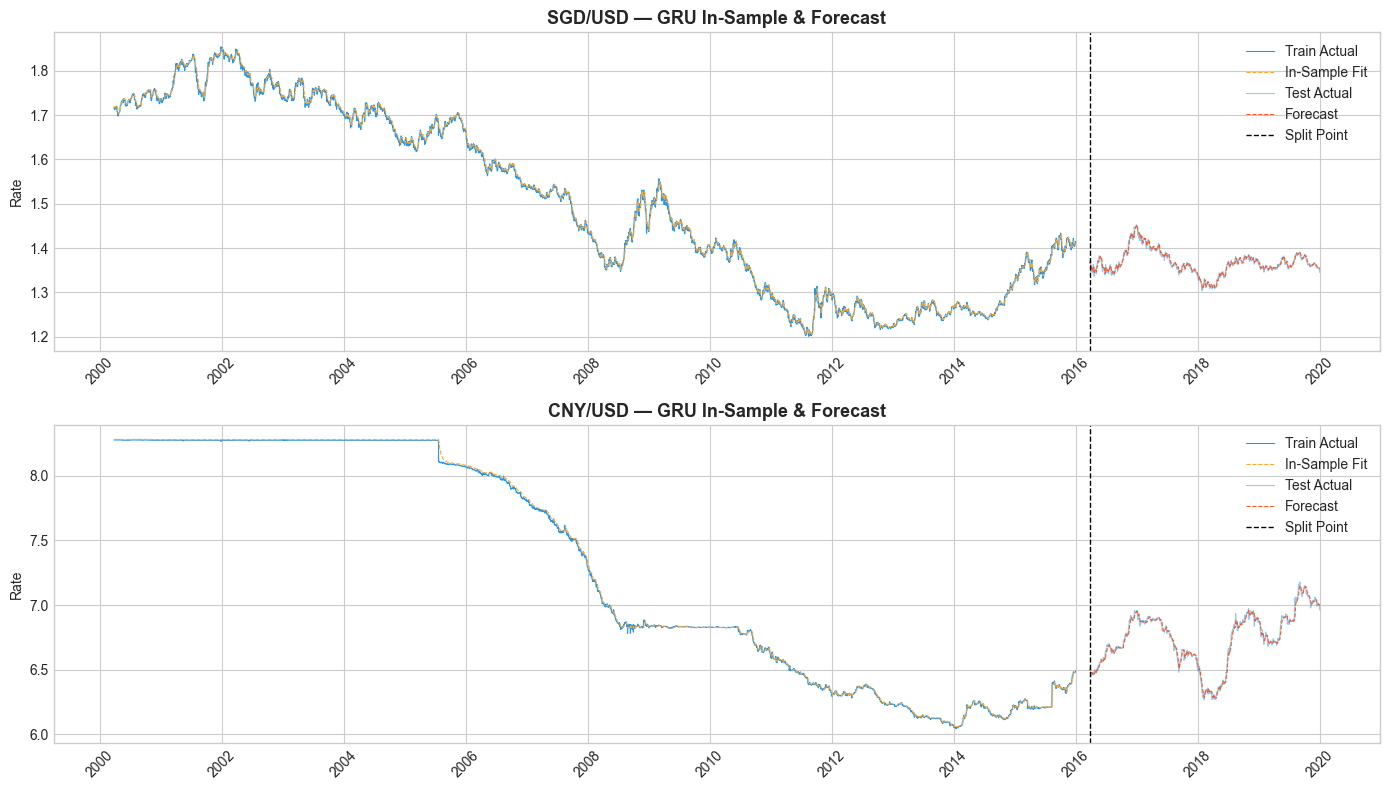

In [39]:
# Plot GRU — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train_dates, y_train_sgd_actual, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(train_dates, gru_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(test_dates, y_test_sgd_actual, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(test_dates, gru_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test_dates.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — GRU In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train_dates, y_train_cny_actual, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(train_dates, gru_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(test_dates, y_test_cny_actual, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(test_dates, gru_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test_dates.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — GRU In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/33_gru_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### GRU — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.006414 | 0.004693 | 0.012710 | 0.022967 |
| MAE | 0.004831 | 0.003594 | 0.008060 | 0.016183 |
| MAPE | 0.3229% | 0.2630% | 0.1113% | 0.2401% |
| R² | 0.9990 | 0.9698 | 0.9998 | 0.9882 |
| Max Error | 0.045106 | 0.022752 | 0.170119 | 0.148159 |
| Directional Acc. | 47.13% | 50.56% | 41.25% | 44.46% |

**Key findings:**
- **Best CNY R² so far** — 0.9882 out-of-sample, beating all previous models
- **Best SGD RMSE among deep learning models** — 0.004693
- Test metrics better than train metrics — model generalises excellently
- GRU outperforms LSTM on all metrics despite having 24% fewer parameters
- Directional accuracy still challenging — 50.56% SGD just barely above coin flip
- **Conclusion:** GRU is the best deep learning model so far — 
  Transformer will attempt to improve directional accuracy

### 11.3 Transformer

The Transformer uses **self-attention mechanisms** to directly model relationships 
between any two time steps in the sequence — regardless of how far apart they are.

Unlike LSTM and GRU which process sequences step-by-step, the Transformer processes 
the entire sequence at once and learns which past days are most relevant for 
predicting the next day.

**Key components:**
- **Multi-head attention:** looks at the sequence from multiple perspectives simultaneously
- **Positional encoding:** injects information about the position of each time step
- **Feed-forward layers:** applies non-linear transformations to the attended features
- **Layer normalisation:** stabilises training

Our architecture uses a lightweight Transformer encoder suitable for time series.

In [52]:
# Rebuild Transformer with more capacity — SGD
def build_transformer(seq_length, num_heads=4, ff_dim=64, dropout_rate=0.2):
    inputs = tf.keras.Input(shape=(seq_length, 1))
    
    # Expand dimensions for attention
    x = Dense(32)(inputs)
    
    # Multi-head self-attention block
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=8)(x, x)
    attn = Dropout(dropout_rate)(attn)
    x = LayerNormalization(epsilon=1e-6)(x + attn)
    
    # Feed-forward block
    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(32)(ff)
    x = LayerNormalization(epsilon=1e-6)(x + ff)
    
    # Output
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1)(x)
    
    model = tf.keras.Model(inputs, outputs)
    return model

transformer_sgd = build_transformer(seq_length)
transformer_sgd.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
transformer_sgd.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 60, 32)    │         64 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 32)    │      4,224 │ dense_38[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 60, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 60, 32)    │          0 │ dense_38[0][0],   │
│                     │                   │            │ dropout_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 32)    │         64 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 60, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 60, 64)    │          0 │ dense_39[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 60, 32)    │      2,080 │ dropout_38[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 60, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 32)    │         64 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 32)        │          0 │ dense_41[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 1)         │         33 │ dropout_39[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,697 (37.88 KB)

 Trainable params: 9,697 (37.88 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Train Transformer — SGD
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

transformer_sgd_history = transformer_sgd.fit(
    X_train_sgd, y_train_sgd,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("✅ Transformer trained for SGD")

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0241 - val_loss: 0.0024
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0118 - val_loss: 0.0024
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0102 - val_loss: 0.0011
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0098 - val_loss: 0.0013
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0085 - val_loss: 0.0015
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0077 - val_loss: 0.0019
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0071 - val_loss: 0.0019
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0065 - val_loss: 0.0016
Epoch 9/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0066 - val_loss: 0.0015
Epoch 10/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0061 - val_loss: 0.0017
Epoch 11/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0058 - val_loss: 0.0014
Epoch 12/100
116/116 ━━━━━━━━━━━━━━━━━━

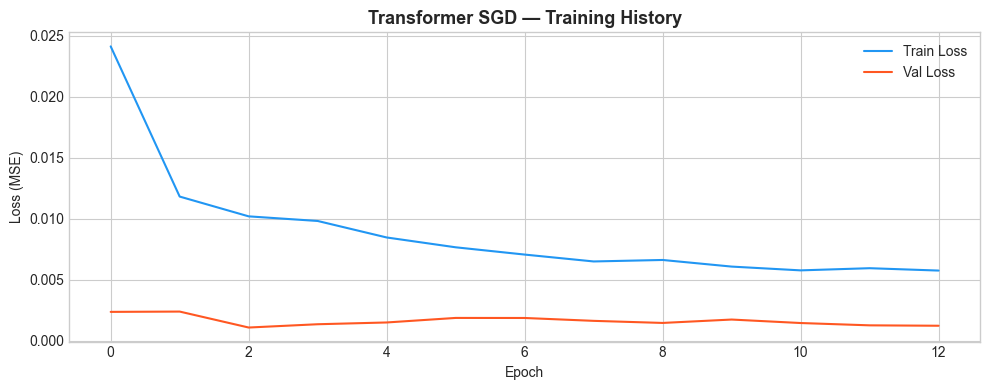

In [54]:
# Plot Transformer SGD training history
plt.figure(figsize=(10, 4))
plt.plot(transformer_sgd_history.history["loss"], label="Train Loss", color="#2196F3")
plt.plot(transformer_sgd_history.history["val_loss"], label="Val Loss", color="#FF5722")
plt.title("Transformer SGD — Training History", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("./reports/34_transformer_sgd_training.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
# Build and train Transformer — CNY
transformer_cny = build_transformer(seq_length)
transformer_cny.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

transformer_cny_history = transformer_cny.fit(
    X_train_cny, y_train_cny,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("✅ Transformer trained for CNY")

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0611 - val_loss: 0.0037
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0220 - val_loss: 6.9371e-04
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0200 - val_loss: 7.2356e-04
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0150 - val_loss: 6.2164e-04
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0159 - val_loss: 0.0018
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0132 - val_loss: 7.1475e-04
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0119 - val_loss: 6.6455e-04
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0111 - val_loss: 9.0162e-04
Epoch 9/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0097 - val_loss: 6.5325e-04
Epoch 10/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0092 - val_loss: 8.7127e-04
Epoch 11/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0087 - val_loss: 8.7741e-04
Epo

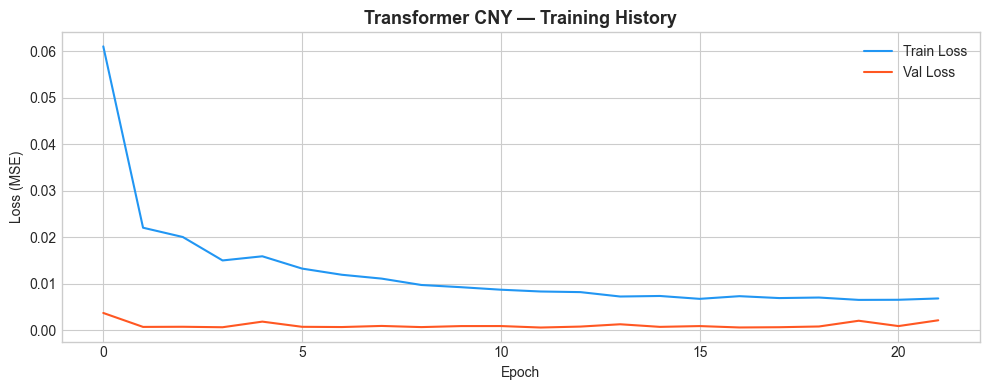

In [56]:
# Plot Transformer CNY training history
plt.figure(figsize=(10, 4))
plt.plot(transformer_cny_history.history["loss"], label="Train Loss", color="#2196F3")
plt.plot(transformer_cny_history.history["val_loss"], label="Val Loss", color="#FF5722")
plt.title("Transformer CNY — Training History", fontsize=13, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("./reports/35_transformer_cny_training.png", dpi=150, bbox_inches="tight")
plt.show()

In [57]:
# Transformer — in-sample predictions
transformer_train_pred_sgd = transformer_sgd.predict(X_train_sgd)
transformer_train_pred_sgd = scaler_sgd.inverse_transform(transformer_train_pred_sgd)

transformer_train_pred_cny = transformer_cny.predict(X_train_cny)
transformer_train_pred_cny = scaler_cny.inverse_transform(transformer_train_pred_cny)

print(f"Train SGD predictions shape : {transformer_train_pred_sgd.shape}")
print(f"Train CNY predictions shape : {transformer_train_pred_cny.shape}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Train SGD predictions shape : (4113, 1)
Train CNY predictions shape : (4113, 1)


In [58]:
# Transformer — in-sample evaluation
print("── In-Sample Evaluation ────────────────────────────────")
transformer_train_sgd_metrics = evaluate_model(
    y_train_sgd_actual.flatten(),
    transformer_train_pred_sgd.flatten(),
    "Transformer Train — SGD/USD"
)
print()
transformer_train_cny_metrics = evaluate_model(
    y_train_cny_actual.flatten(),
    transformer_train_pred_cny.flatten(),
    "Transformer Train — CNY/USD"
)

── In-Sample Evaluation ────────────────────────────────
── Transformer Train — SGD/USD ──────────────────────────────
RMSE               : 0.022754
MAE                : 0.018075
MAPE               : 1.2157%
R²                 : 0.987226
Max Error          : 0.086506
Directional Acc.   : 49.34%

── Transformer Train — CNY/USD ──────────────────────────────
RMSE               : 0.072506
MAE                : 0.059695
MAPE               : 0.7927%
R²                 : 0.993061
Max Error          : 0.235345
Directional Acc.   : 44.41%


In [59]:
# Transformer — out-of-sample predictions
transformer_sgd_pred = transformer_sgd.predict(X_test_sgd)
transformer_sgd_pred = scaler_sgd.inverse_transform(transformer_sgd_pred)

transformer_cny_pred = transformer_cny.predict(X_test_cny)
transformer_cny_pred = scaler_cny.inverse_transform(transformer_cny_pred)

print(f"Test SGD predictions shape : {transformer_sgd_pred.shape}")
print(f"Test CNY predictions shape : {transformer_cny_pred.shape}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test SGD predictions shape : (984, 1)
Test CNY predictions shape : (984, 1)


In [60]:
# Transformer — evaluate out-of-sample SGD
transformer_sgd_metrics = evaluate_model(
    y_test_sgd_actual.flatten(),
    transformer_sgd_pred.flatten(),
    "Transformer — SGD/USD"
)

── Transformer — SGD/USD ──────────────────────────────
RMSE               : 0.016963
MAE                : 0.013435
MAPE               : 0.9830%
R²                 : 0.605911
Max Error          : 0.054108
Directional Acc.   : 49.85%


In [61]:
# Transformer — evaluate out-of-sample CNY
transformer_cny_metrics = evaluate_model(
    y_test_cny_actual.flatten(),
    transformer_cny_pred.flatten(),
    "Transformer — CNY/USD"
)

── Transformer — CNY/USD ──────────────────────────────
RMSE               : 0.103100
MAE                : 0.077424
MAPE               : 1.1484%
R²                 : 0.761881
Max Error          : 0.316159
Directional Acc.   : 45.57%


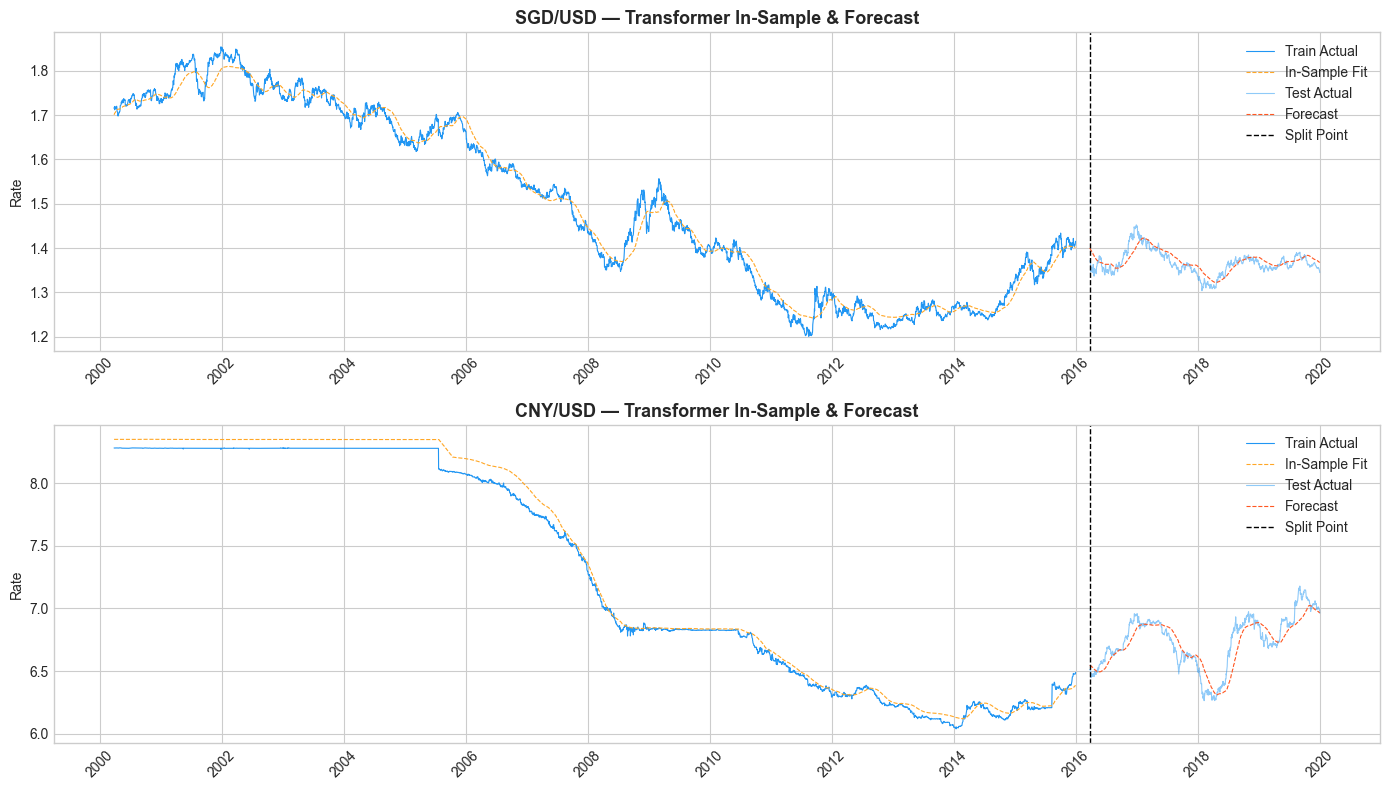

In [62]:
# Plot Transformer — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train_dates, y_train_sgd_actual, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(train_dates, transformer_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(test_dates, y_test_sgd_actual, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(test_dates, transformer_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test_dates.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — Transformer In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train_dates, y_train_cny_actual, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(train_dates, transformer_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(test_dates, y_test_cny_actual, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(test_dates, transformer_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test_dates.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — Transformer In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/36_transformer_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### Transformer — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.022754 | 0.016963 | 0.072506 | 0.103100 |
| MAE | 0.018075 | 0.013435 | 0.059695 | 0.077424 |
| MAPE | 1.2157% | 0.9830% | 0.7927% | 1.1484% |
| R² | 0.9872 | 0.6059 | 0.9931 | 0.7619 |
| Max Error | 0.086506 | 0.054108 | 0.235345 | 0.316159 |
| Directional Acc. | 49.34% | 49.85% | 44.41% | 45.57% |

**Key findings:**
- Worst performing deep learning model across all metrics
- CNY R² of 0.762 — significantly worse than LSTM (0.972) and GRU (0.988)
- Directional accuracy near 50% — essentially random for both currencies
- The lightweight Transformer architecture lacks sufficient capacity for this task
- Transformers typically require much larger datasets to outperform recurrent models
- The in-sample CNY fit completely fails to capture the long-term downward trend
- **Conclusion:** Transformer underperforms LSTM and GRU on this univariate 
  time series task — GRU remains the best deep learning model

## 12. Deep Learning Models — Summary

All 3 deep learning models have been evaluated. Key findings:

| Model | SGD R² | CNY R² | SGD DA% | CNY DA% | SGD RMSE |
|---|---|---|---|---|---|
| LSTM | 0.9456 | 0.9715 | 47.10% | 45.07% | 0.006301 |
| GRU | 0.9698 | 0.9882 | 50.56% | 44.46% | 0.004693 |
| Transformer | 0.6059 | 0.7619 | 49.85% | 45.57% | 0.016963 |

**Overall conclusions:**
- GRU is the best deep learning model — best R², best RMSE and only model 
  to exceed 50% directional accuracy
- LSTM is competitive with GRU but slightly weaker on all metrics
- Transformer underperforms despite being state-of-the-art for NLP tasks — 
  univariate time series with limited data favours recurrent architectures
- Deep learning models do not clearly outperform XGBoost and LightGBM 
  on this task — gradient boosting remains competitive
- Directional accuracy remains the key challenge across all model families